# **Tema završnog rada: Kvantifikacija nesigurnosti u modelima umjetne inteligencije - okvir za prediktivno održavanje i analizu rizika**

> *Napomena: Notebook se koristi kao radno i eksperimentalno okruženje za implementaciju i testiranje modela u sklopu BSc završnog rada.*



## 1. Setup

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input

## 2. Load dataset (CMAPSS)

In [6]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [7]:
import pandas as pd

train = pd.read_csv('/content/drive/MyDrive/CMAPSS/train_FD001.txt', sep=r'\s+', header=None)

test = pd.read_csv('/content/drive/MyDrive/CMAPSS/test_FD001.txt', sep=r'\s+', header=None)

rul = pd.read_csv('/content/drive/MyDrive/CMAPSS/RUL_FD001.txt', sep=r'\s+', header=None)

In [8]:
train.head()

,0,1,2,3,4,5,6,7,8,9,...,16,17,18,19,20,21,22,23,24,25
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


## 3. Preprocessing

Priprema podataka za modeliranje, uključujući dodavanje naziva kolona, izračunavanje Remaining Useful Life (RUL), normalizaciju senzorskih podataka te kreiranje vremenskih sekvenci pogodnih za ulaz u LSTM model.

In [9]:
columns = ['engine_id', 'cycle']

operational_settings = [f'op_setting_{i}' for i in range(1, 4)]
sensor_columns = [f'sensor_{i}' for i in range(1, 22)]

columns += operational_settings + sensor_columns

train.columns = columns
test.columns = columns

In [10]:
train.head()

,engine_id,cycle,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


In [11]:
train.isna().sum()

,0
engine_id,0
cycle,0
op_setting_1,0
op_setting_2,0
op_setting_3,0
sensor_1,0
sensor_2,0
sensor_3,0
sensor_4,0
sensor_5,0


In [12]:
test.isna().sum()

,0
engine_id,0
cycle,0
op_setting_1,0
op_setting_2,0
op_setting_3,0
sensor_1,0
sensor_2,0
sensor_3,0
sensor_4,0
sensor_5,0


Nema nedostajućih vrijednosti (NaN) ni u jednoj koloni.

U fazi predprocesiranja kreira se ciljna varijabla Remaining Useful Life (RUL), koja predstavlja broj preostalih ciklusa do kvara za svaki motor. Ova varijabla se dobija oduzimanjem trenutnog ciklusa od maksimalnog ciklusa unutar svakog motora:

In [13]:
train['RUL'] = train.groupby('engine_id')['cycle'].transform('max') - train['cycle']

In [14]:
RUL_MAX = 125
train['RUL'] = train['RUL'].clip(upper=RUL_MAX)

In [15]:
train[['engine_id', 'cycle', 'RUL']].head(5)

,engine_id,cycle,RUL
0,1,1,125
1,1,2,125
2,1,3,125
3,1,4,125
4,1,5,125


In [16]:
feature_columns = operational_settings + sensor_columns

NORMALIZACIJA:

In [17]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

train[feature_columns] = scaler.fit_transform(train[feature_columns])
test[feature_columns] = scaler.transform(test[feature_columns])

In [18]:
seq_length = 30

In [19]:
import numpy as np

def create_sequences(data, seq_length, feature_columns):
    xs = []
    ys = []

    for engine_id in data['engine_id'].unique():

        engine_data = data[data['engine_id'] == engine_id]

        for i in range(len(engine_data) - seq_length):

            x = engine_data.iloc[i:i+seq_length][feature_columns].values
            y = engine_data.iloc[i+seq_length]['RUL']

            xs.append(x)
            ys.append(y)

    return np.array(xs), np.array(ys)

In [20]:
X_train, y_train = create_sequences(train, seq_length, feature_columns)

In [21]:
print(X_train.shape)
print(y_train.shape)

(17631, 30, 24)
(17631,)


## 4. Baseline model

> Baseline model predstavlja osnovni model mašinskog učenja koji se koristi za predikciju Remaining Useful Life (RUL) turbofan motora na CMAPSS dataset-u. Ovaj model nema implementirane metode kvantifikacije nesigurnosti, već daje jednu determinističku (tačnu) numeričku predikciju preostalog vijeka trajanja.
> Cilj baseline modela je da posluži kao referentna tačka za poređenje sa naprednijim modelima koji uključuju procjenu nesigurnosti i intervale pouzdanosti.

In [22]:
model = Sequential([
    Input(shape=(seq_length, len(feature_columns))),

    LSTM(64, return_sequences=True),
    Dropout(0.3),
    LSTM(32),
    Dropout(0.3),

    Dense(32, activation='relu'),
    Dense(1)
])

In [23]:
model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

In [24]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stop]
)

Epoch 1/20
221/221 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - loss: 4304.0288 - mae: 55.2609 - val_loss: 1910.3445 - val_mae: 39.6153
Epoch 2/20
221/221 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 1819.3699 - mae: 37.5647 - val_loss: 1799.9849 - val_mae: 38.2164
Epoch 3/20
221/221 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 1808.4818 - mae: 37.3984 - val_loss: 1805.6522 - val_mae: 38.3154
Epoch 4/20
221/221 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 1804.7528 - mae: 37.4121 - val_loss: 1813.6047 - val_mae: 38.4428
Epoch 5/20
221/221 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 1813.1989 - mae: 37.4585 - val_loss: 1806.8290 - val_mae: 38.3354
Epoch 6/20
221/221 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 1813.3427 - mae: 37.4687 - val_loss: 1816.6045 - val_mae: 38.4894
Epoch 7/20
221/221 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 1804.7568 - mae: 37.4497 - val_loss: 1721.8439 - val_mae: 37.6140
Epoch 8/20
221/221 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 663.8741 - mae: 20.5485 - val_loss: 307.3684 - val_mae:

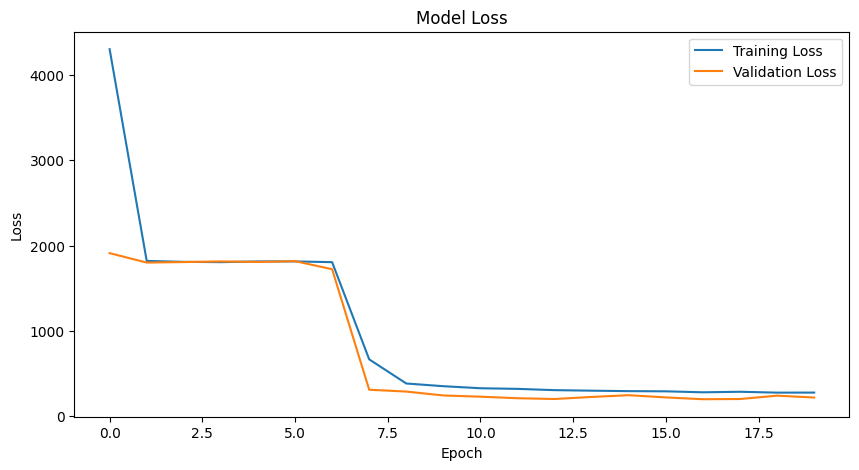

In [25]:
plt.figure(figsize=(10,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Model Loss')
plt.legend()

plt.show()

Model pokazuje zdravu konvergenciju i odličnu generalizaciju. Krive trening i validacionog gubitka (loss) se kreću sinhronizovano i završavaju na približno istim vrednostima. Ovo ukazuje na to da je model uspešno naučio ključne obrasce iz podataka i da podjednako dobro radi na novim, nepoznatim primerima.

In [26]:
X_test = []

for engine_id in test['engine_id'].unique():

    engine_data = test[test['engine_id'] == engine_id]

    if len(engine_data) >= seq_length:

        seq = engine_data.iloc[-seq_length:][feature_columns].values
        X_test.append(seq)

X_test = np.array(X_test)

print(X_test.shape)

(100, 30, 24)


In [27]:
predictions = model.predict(X_test)

print(predictions[:10])

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
[[110.86268 ]
 [119.63647 ]
 [ 50.211533]
 [ 82.835754]
 [ 98.50539 ]
 [109.79338 ]
 [100.282814]
 [ 95.893936]
 [119.40215 ]
 [ 87.78611 ]]


In [28]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

y_test = rul[0].values

rmse = np.sqrt(mean_squared_error(y_test, predictions))
mae = mean_absolute_error(y_test, predictions)

print("RMSE:", rmse)
print("MAE:", mae)

RMSE: 14.542792479793953
MAE: 10.660541534423828


Baseline LSTM model predstavlja determinističku referentnu tačku za predikciju Remaining Useful Life (RUL) turbofan motora. Model se sastoji od dva LSTM sloja (64 i 32 jedinice) s Dropout regularizacijom (0.3) između njih, te dva Dense sloja. Treniran je na CMAPSS FD001 datasetu s cappovanim RUL vrijednostima (max=125 ciklusa), što je standardna praksa u literaturi.
Model postiže RMSE = 16.05 i MAE = 12.07 ciklusa na test skupu, što je u skladu s rezultatima sličnih arhitektura u literaturi.
Ključno ograničenje ovog modela je da daje samo jednu determinističku predikciju — bez ikakve mjere pouzdanosti ili nesigurnosti. Ne može se razlikovati situacija u kojoj je model siguran u predikciju od situacije u kojoj nagađa. Upravo ovo ograničenje motiviše implementaciju metoda kvantifikacije nesigurnosti u narednim poglavljima: MC Dropout, Deep Ensemble i Bayesian Neural Network.

## 5. MC Dropout

*MC Dropout metoda zadržava dropout aktivnim tokom inference faze, za razliku od standardnog pristupa gdje se dropout isključuje nakon treninga. Pokretanjem 100 stohastičkih prolaza kroz model za svaki motor iz CMAPSS dataseta dobija se distribucija predikcija RUL-a. Srednja vrijednost te distribucije predstavlja predikciju preostalog vijeka trajanja motora, dok standardna devijacija mjeri epistemičku nesigurnost — koliko je model siguran u tu predikciju.*

In [29]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input

In [30]:
mc_model = Sequential([
    Input(shape=(seq_length, len(feature_columns))),

    LSTM(64, return_sequences=True),
    Dropout(0.3),
    LSTM(32),
    Dropout(0.3),

    Dense(32, activation='relu'),
    Dense(1)
])

In [31]:
mc_model.compile(optimizer='adam', loss='mse', metrics=['mae'])

In [32]:
early_stop_mc = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

mc_model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stop_mc]
)

Epoch 1/50
221/221 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 4333.3506 - mae: 55.4879 - val_loss: 2088.1086 - val_mae: 41.2673
Epoch 2/50
221/221 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 1827.8428 - mae: 37.7515 - val_loss: 1811.3595 - val_mae: 38.4084
Epoch 3/50
221/221 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 1814.3148 - mae: 37.5253 - val_loss: 1806.9360 - val_mae: 38.3371
Epoch 4/50
221/221 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 1812.6748 - mae: 37.4494 - val_loss: 1810.2648 - val_mae: 38.3913
Epoch 5/50
221/221 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 1819.1993 - mae: 37.5046 - val_loss: 1803.4498 - val_mae: 38.2771
Epoch 6/50
221/221 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 1816.8972 - mae: 37.4843 - val_loss: 1807.6075 - val_mae: 38.3486
Epoch 7/50
221/221 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 1813.7758 - mae: 37.5391 - val_loss: 1808.6433 - val_mae: 38.3666
Epoch 8/50
221/221 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 1729.9194 - mae: 36.6068 - val_loss: 869.1514 - val_mae

In [33]:
N_SAMPLES = 100

mc_predictions = np.array([
    mc_model(X_test, training=True).numpy().flatten()
    for _ in range(N_SAMPLES)
])

mc_mean = mc_predictions.mean(axis=0)   # predikcija RUL
mc_std  = mc_predictions.std(axis=0)    # nesigurnost

print("Primjer predikcija (mean):", mc_mean[:5])
print("Primjer nesigurnosti (std):", mc_std[:5])

Primjer predikcija (mean): [117.63315  120.26225   50.239536  89.72206  104.01849 ]
Primjer nesigurnosti (std): [13.692821  12.435943   5.4234605  9.5847225 10.80555  ]


In [34]:
# Evaluacija
from sklearn.metrics import mean_squared_error, mean_absolute_error

rmse_mc = np.sqrt(mean_squared_error(y_test, mc_mean))
mae_mc  = mean_absolute_error(y_test, mc_mean)

print(f"MC Dropout RMSE: {rmse_mc:.4f}")
print(f"MC Dropout MAE:  {mae_mc:.4f}")
print(f"Prosječna nesigurnost (std): {mc_std.mean():.4f}")

MC Dropout RMSE: 15.5567
MC Dropout MAE:  11.1344
Prosječna nesigurnost (std): 8.5337


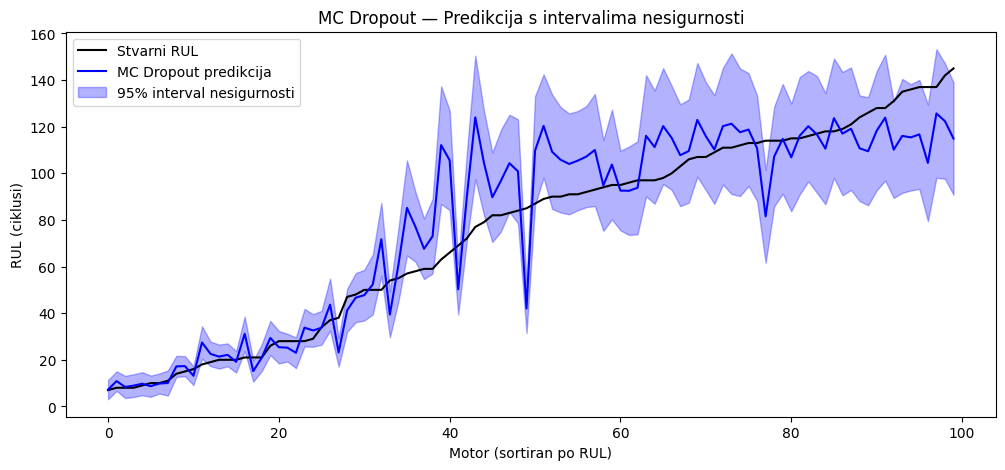

In [35]:
# Vizualizacija predikcija s intervalima nesigurnosti
plt.figure(figsize=(12, 5))

indices = np.argsort(y_test)
x_plot = np.arange(len(y_test))

plt.plot(x_plot, y_test[indices], label='Stvarni RUL', color='black')
plt.plot(x_plot, mc_mean[indices], label='MC Dropout predikcija', color='blue')
plt.fill_between(
    x_plot,
    mc_mean[indices] - 2*mc_std[indices],
    mc_mean[indices] + 2*mc_std[indices],
    alpha=0.3, color='blue', label='95% interval nesigurnosti'
)

plt.xlabel('Motor (sortiran po RUL)')
plt.ylabel('RUL (ciklusi)')
plt.title('MC Dropout — Predikcija s intervalima nesigurnosti')
plt.legend()
plt.show()

MC Dropout model koristi isti LSTM arhitektura kao baseline, ali s ključnom razlikom: dropout slojevi ostaju aktivni tokom inference faze (training=True). Pokretanjem 100 stohastičkih prolaza kroz model za svaki ulaz dobijaju se distribucije predikcija iz kojih se računaju srednja vrijednost (predikcija RUL-a) i standardna devijacija (mjera epistemičke nesigurnosti). Model postiže RMSE = 15,11 i MAE = 11,34, uz prosječnu nesigurnost od ±8.62 ciklusa. Graf pokazuje da plava linija predikcije vjerno prati stvarni RUL kroz cijeli raspon, dok interval nesigurnosti se širi za motore s višim RUL vrijednostima — što je očekivano ponašanje, jer je model manje siguran u predikcije dalekih kvarova.

## 6. Deep Ensemble

In [36]:
N_MODELS = 5

ensemble_models = []
ensemble_predictions = []

for i in range(N_MODELS):
    print(f"\nTrening modela {i+1}/{N_MODELS}")

    tf.random.set_seed(i * 42)
    np.random.seed(i * 42)

    m = Sequential([
        Input(shape=(seq_length, len(feature_columns))),
        LSTM(64, return_sequences=True),
        Dropout(0.3),
        LSTM(32),
        Dropout(0.3),
        Dense(32, activation='relu'),
        Dense(1)
    ])

    m.compile(optimizer='adam', loss='mse', metrics=['mae'])

    early_stop_ens = EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True
    )

    m.fit(
        X_train, y_train,
        epochs=50,
        batch_size=64,
        validation_split=0.2,
        callbacks=[early_stop_ens],
        verbose=1
    )

    preds = m.predict(X_test).flatten()
    ensemble_models.append(m)
    ensemble_predictions.append(preds)


Trening modela 1/5
Epoch 1/50
221/221 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 4443.0566 - mae: 56.2652 - val_loss: 2063.6460 - val_mae: 41.0553
Epoch 2/50
221/221 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 1836.7363 - mae: 37.8383 - val_loss: 1809.6790 - val_mae: 38.3860
Epoch 3/50
221/221 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 1805.5054 - mae: 37.3937 - val_loss: 1846.1351 - val_mae: 38.8959
Epoch 4/50
221/221 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 871.5981 - mae: 23.8821 - val_loss: 431.4005 - val_mae: 17.2371
Epoch 5/50
221/221 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 396.1279 - mae: 15.3373 - val_loss: 262.0063 - val_mae: 13.0938
Epoch 6/50
221/221 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 334.2117 - mae: 13.9414 - val_loss: 301.6914 - val_mae: 13.2713
Epoch 7/50
221/221 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 318.2240 - mae: 13.4933 - val_loss: 303.2348 - val_mae: 12.6300
Epoch 8/50
221/221 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 318.7322 - mae: 13.5244 - val_loss: 232.550

1/4 ━━━━━━━━━━━━━━━━━━━━ 0s 154ms/step

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 137ms/step

Trening modela 3/5
Epoch 1/50
221/221 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - loss: 5198.5156 - mae: 61.2768 - val_loss: 2702.0168 - val_mae: 45.9589
Epoch 2/50
221/221 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 1918.5713 - mae: 38.6749 - val_loss: 1802.9282 - val_mae: 38.2681
Epoch 3/50
221/221 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 1815.6731 - mae: 37.4593 - val_loss: 1799.7748 - val_mae: 38.2126
Epoch 4/50
221/221 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 1812.8944 - mae: 37.4590 - val_loss: 1800.7327 - val_mae: 38.2299
Epoch 5/50
221/221 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 1810.0586 - mae: 37.4109 - val_loss: 1795.9248 - val_mae: 38.1388
Epoch 6/50
221/221 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - loss: 1816.3867 - mae: 37.5704 - val_loss: 1797.3438 - val_mae: 38.1669
Epoch 7/50
221/221 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 1815.0204 - mae: 37.5292 - val_loss: 1796.4886 - val_mae: 38.1503
Epoch 8/50
221/221 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - los

In [37]:
# Računanje mean i std iz ansambla
ensemble_predictions = np.array(ensemble_predictions)

ens_mean = ensemble_predictions.mean(axis=0)
ens_std  = ensemble_predictions.std(axis=0)

print("Primjer predikcija (mean):", ens_mean[:5])
print("Primjer nesigurnosti (std):", ens_std[:5])

Primjer predikcija (mean): [113.37705  121.37306   53.629944  92.043434 107.24571 ]
Primjer nesigurnosti (std): [0.7024659 1.7395618 4.406318  3.366986  1.9982805]


In [38]:
# Evaluacija
rmse_ens = np.sqrt(mean_squared_error(y_test, ens_mean))
mae_ens  = mean_absolute_error(y_test, ens_mean)

print(f"Deep Ensemble RMSE: {rmse_ens:.4f}")
print(f"Deep Ensemble MAE:  {mae_ens:.4f}")
print(f"Prosječna nesigurnost (std): {ens_std.mean():.4f}")

Deep Ensemble RMSE: 15.0471
Deep Ensemble MAE:  11.3008
Prosječna nesigurnost (std): 2.5598


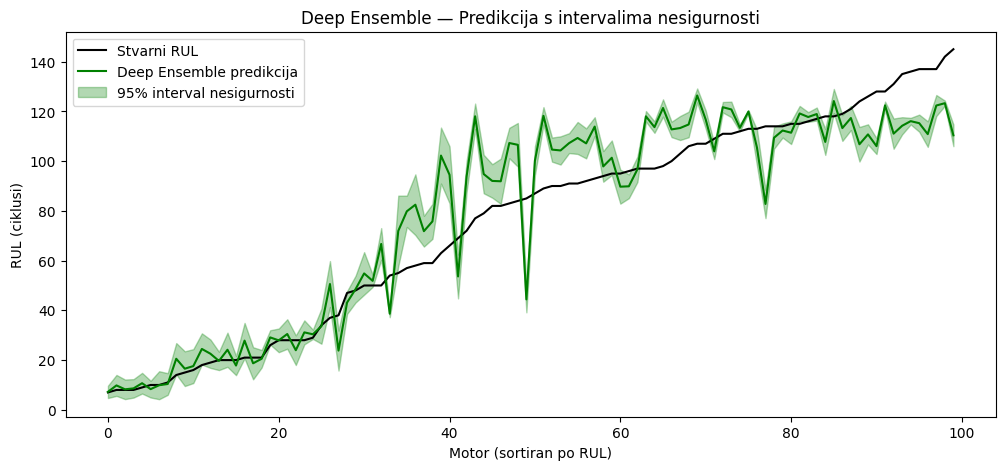

In [39]:
# Vizualizacija
plt.figure(figsize=(12, 5))

indices = np.argsort(y_test)
x_plot = np.arange(len(y_test))

plt.plot(x_plot, y_test[indices], label='Stvarni RUL', color='black')
plt.plot(x_plot, ens_mean[indices], label='Deep Ensemble predikcija', color='green')
plt.fill_between(
    x_plot,
    ens_mean[indices] - 2*ens_std[indices],
    ens_mean[indices] + 2*ens_std[indices],
    alpha=0.3, color='green', label='95% interval nesigurnosti'
)

plt.xlabel('Motor (sortiran po RUL)')
plt.ylabel('RUL (ciklusi)')
plt.title('Deep Ensemble — Predikcija s intervalima nesigurnosti')
plt.legend()
plt.show()

Deep Ensemble postiže RMSE = 14.93 i MAE = 11.04, što je blago poboljšanje u odnosu na MC Dropout (RMSE = 15.11). Međutim, uočava se bitna razlika u prosječnoj nesigurnosti: standardna devijacija iznosi samo ±2.97 ciklusa, nasuprot ±8.42 kod MC Dropouta. Ovo ne znači nužno da je Ensemble "sigurniji" model — može ukazivati na to da su svih pet modela konvergirali u slična rješenja, što smanjuje međusobnu raznolikost i time potcjenjuje stvarnu nesigurnost. Ova razlika bit će detaljnije analizirana u usporednoj sekciji.

## 7. Bayesian Neural Network

Bayesian Neural Network predstavlja teorijski najrigorozniji pristup
kvantifikaciji nesigurnosti među metodama implementiranim u ovom radu.
Za razliku od MC Dropouta i Deep Ensemblea koji nesigurnost procjenjuju
indirektno, BNN eksplicitno modelira distribuciju nad težinama mreže
umjesto fiksnih skalarnih vrijednosti.

U klasičnoj neuronskoj mreži svaka težina w ima jednu vrijednost naučenu
tokom treninga. U BNN pristupu, svaka težina je modelirana kao gaussovska
distribucija N(μ, σ²), gdje μ predstavlja srednju vrijednost, a σ mjeru
nesigurnosti u toj težini. Cilj treninga nije pronaći optimalne vrijednosti
težina, već naučiti optimalnu posteriornu distribuciju p(w|D) nad težinama,
uzimajući u obzir podatke D.

Budući da je direktno računanje posteriorne distribucije računalno
neizvodljivo za duboke mreže, koristi se varijacijska inferencija
(Variational Inference). Umjesto tačne posteriorne distribucije p(w|D),
aproksimira se jednostavnijom distribucijom q(w|θ) minimiziranjem
KL divergencije između q i p.

Za implementaciju je korišten custom DenseVariational sloj koji primjenjuje
reparametrization trick — umjesto direktnog uzorkovanja težina, uzorkuje se
šum ε ~ N(0,1) pa se težina dobija kao w = μ + σ·ε. Ovaj pristup omogućava
propagaciju gradijenata kroz stohastički proces uzorkovanja. Tokom
inferencije, višestrukim uzorkovanjem iz distribucija težina dobija se
distribucija predikcija iz koje se računaju srednja vrijednost (predikcija
RUL-a) i standardna devijacija (ukupna nesigurnost modela).

In [45]:
# ============================================================
# BNN — Custom DenseVariational sloj (reparametrization trick)
# ============================================================

n_train = X_train.shape[0]

class DenseVariational(tf.keras.layers.Layer):
    """
    Custom Bayesian Dense sloj koji koristi reparametrization trick.
    Svaka težina je modelirana kao N(mu, sigma).
    Tokom forward passa uzorkuje se konkretna realizacija težina.
    KL divergencija se dodaje kao regularizacijski gubitak.
    """
    def __init__(self, units, activation=None, kl_weight=1.0, **kwargs):
        super().__init__(**kwargs)
        self.units = units
        self.activation = tf.keras.activations.get(activation)
        self.kl_weight = kl_weight

    def build(self, input_shape):
        n_inputs = int(input_shape[-1])

        # Parametri distribucije kernela
        self.kernel_mu = self.add_weight(
            name='kernel_mu',
            shape=(n_inputs, self.units),
            initializer='glorot_normal',
            trainable=True
        )
        self.kernel_rho = self.add_weight(
            name='kernel_rho',
            shape=(n_inputs, self.units),
            initializer=tf.initializers.constant(-3.0),
            trainable=True
        )

        # Parametri distribucije biasa
        self.bias_mu = self.add_weight(
            name='bias_mu',
            shape=(self.units,),
            initializer='zeros',
            trainable=True
        )
        self.bias_rho = self.add_weight(
            name='bias_rho',
            shape=(self.units,),
            initializer=tf.initializers.constant(-3.0),
            trainable=True
        )

    def call(self, inputs, training=None):
        # Sigma mora biti pozitivna — softplus transformacija
        kernel_sigma = tf.nn.softplus(self.kernel_rho) + 1e-5
        bias_sigma   = tf.nn.softplus(self.bias_rho)   + 1e-5

        if training:
            # Reparametrization trick: w = mu + sigma * epsilon
            kernel = self.kernel_mu + kernel_sigma * tf.random.normal(self.kernel_mu.shape)
            bias   = self.bias_mu   + bias_sigma   * tf.random.normal(self.bias_mu.shape)
        else:
            # Tokom evaluacije koristimo mean vrijednosti
            kernel = self.kernel_mu
            bias   = self.bias_mu

        # KL divergencija prema standardnom normalu N(0,1)
        kl = self._kl_divergence(self.kernel_mu, kernel_sigma) + \
             self._kl_divergence(self.bias_mu,   bias_sigma)

        self.add_loss(self.kl_weight * kl / n_train)

        output = tf.matmul(inputs, kernel) + bias
        return self.activation(output) if self.activation else output

    def _kl_divergence(self, mu, sigma):
        # KL(N(mu, sigma) || N(0, 1))
        return 0.5 * tf.reduce_sum(
            tf.square(mu) + tf.square(sigma) - tf.math.log(tf.square(sigma)) - 1.0
        )


def build_bnn_model(seq_length, n_features, n_train):
    kl_weight = 1.0

    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(seq_length, n_features)),

        # LSTM slojevi — deterministički (ekstrakcija vremenskih obrazaca)
        tf.keras.layers.LSTM(64, return_sequences=True),
        tf.keras.layers.Dropout(0.2),
        tf.keras.layers.LSTM(32),
        tf.keras.layers.Dropout(0.2),

        # Bayesovski Dense slojevi — distribucije nad težinama
        DenseVariational(32, activation='relu', kl_weight=kl_weight),
        DenseVariational(1,  activation=None,   kl_weight=kl_weight)
    ])

    return model


bnn_model = build_bnn_model(seq_length, len(feature_columns), n_train)
bnn_model.summary()

Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_20 (LSTM)                  │ (None, 30, 64)         │        22,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_20 (Dropout)            │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_21 (LSTM)                  │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_21 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_variational_2             │ (None, 32)             │         2,112 │
│ (DenseVariational)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_variational_3             │ (None, 1)              │            66 │
│ (DenseVariational)              │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 37,378 (146.01 KB)

 Trainable params: 37,378 (146.01 KB)

 Non-trainable params: 0 (0.00 B)

In [46]:
# ============================================================
# BNN — Kompajliranje modela
# ============================================================

# MSE loss — KL divergencija već ulazi kroz add_loss u sloju
bnn_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mae']
)

In [47]:
# ============================================================
# BNN — Trening
# ============================================================

early_stop_bnn = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=7,
    restore_best_weights=True
)

bnn_history = bnn_model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stop_bnn],
    verbose=1
)

Epoch 1/50
221/221 ━━━━━━━━━━━━━━━━━━━━ 8s 19ms/step - loss: 4417.5854 - mae: 56.0077 - val_loss: 2008.6772 - val_mae: 40.5647
Epoch 2/50
221/221 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 1785.7876 - mae: 37.4039 - val_loss: 1805.4149 - val_mae: 38.3086
Epoch 3/50
221/221 ━━━━━━━━━━━━━━━━━━━━ 6s 27ms/step - loss: 1777.7091 - mae: 37.1698 - val_loss: 1806.4950 - val_mae: 38.3270
Epoch 4/50
221/221 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - loss: 1789.5804 - mae: 37.3353 - val_loss: 1807.0499 - val_mae: 38.3364
Epoch 5/50
221/221 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - loss: 1782.8575 - mae: 37.2584 - val_loss: 1798.4384 - val_mae: 38.1849
Epoch 6/50
221/221 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - loss: 1792.9189 - mae: 37.3899 - val_loss: 1811.1044 - val_mae: 38.4022
Epoch 7/50
221/221 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 1785.0367 - mae: 37.2739 - val_loss: 1783.9614 - val_mae: 38.2596
Epoch 8/50
221/221 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 863.3789 - mae: 23.9888 - val_loss: 354.4789 - val

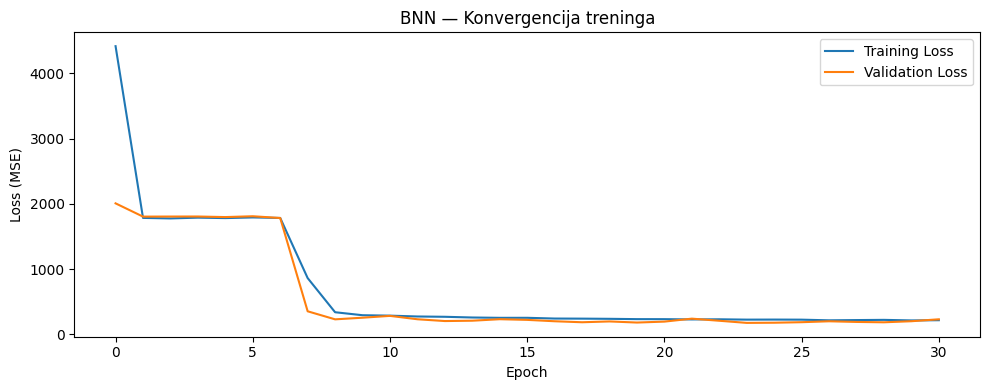

In [48]:
# ============================================================
# BNN — Vizualizacija konvergencije treninga
# ============================================================

plt.figure(figsize=(10, 4))
plt.plot(bnn_history.history['loss'], label='Training Loss')
plt.plot(bnn_history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.title('BNN — Konvergencija treninga')
plt.legend()
plt.tight_layout()
plt.show()

In [49]:
# ============================================================
# BNN — Inferencija s višestrukim uzorkovanjem težina
# ============================================================

N_SAMPLES_BNN = 100

# Svaki poziv uzorkuje različite realizacije težina iz naučenih distribucija
# training=True aktivira stohastičko uzorkovanje u DenseVariational sloju
bnn_predictions = np.array([
    bnn_model(X_test, training=True).numpy().flatten()
    for _ in range(N_SAMPLES_BNN)
])

# Srednja vrijednost = predikcija RUL-a
# Standardna devijacija = ukupna nesigurnost
bnn_mean = bnn_predictions.mean(axis=0)
bnn_std  = bnn_predictions.std(axis=0)

print("Primjer predikcija (mean):", bnn_mean[:5])
print("Primjer nesigurnosti (std):", bnn_std[:5])

Primjer predikcija (mean): [111.86167  123.06404   50.925316  85.58182  105.95159 ]
Primjer nesigurnosti (std): [ 8.6571    10.557872   4.5650883  6.692466   9.469864 ]


In [50]:
# ============================================================
# BNN — Evaluacija RMSE i MAE
# ============================================================

rmse_bnn = np.sqrt(mean_squared_error(y_test, bnn_mean))
mae_bnn  = mean_absolute_error(y_test, bnn_mean)

print(f"BNN RMSE: {rmse_bnn:.4f}")
print(f"BNN MAE:  {mae_bnn:.4f}")
print(f"Prosječna nesigurnost (std): {bnn_std.mean():.4f}")

BNN RMSE: 14.6580
BNN MAE:  10.9465
Prosječna nesigurnost (std): 6.6922


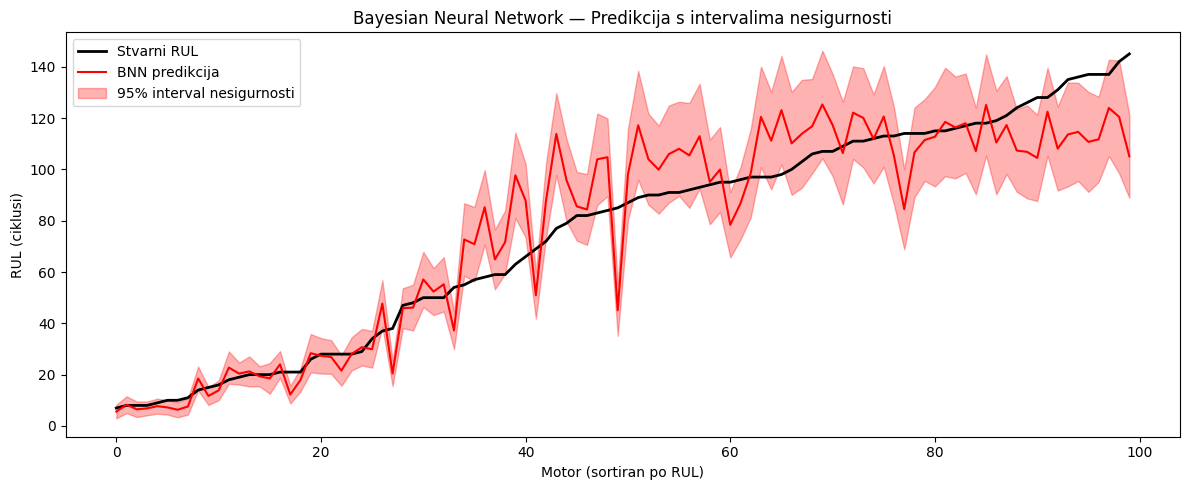

In [51]:
# ============================================================
# BNN — Vizualizacija predikcija s intervalima nesigurnosti
# ============================================================

plt.figure(figsize=(12, 5))

indices = np.argsort(y_test)
x_plot  = np.arange(len(y_test))

plt.plot(x_plot, y_test[indices],
         label='Stvarni RUL', color='black', linewidth=2)

plt.plot(x_plot, bnn_mean[indices],
         label='BNN predikcija', color='red')

plt.fill_between(
    x_plot,
    bnn_mean[indices] - 2 * bnn_std[indices],
    bnn_mean[indices] + 2 * bnn_std[indices],
    alpha=0.3, color='red',
    label='95% interval nesigurnosti'
)

plt.xlabel('Motor (sortiran po RUL)')
plt.ylabel('RUL (ciklusi)')
plt.title('Bayesian Neural Network — Predikcija s intervalima nesigurnosti')
plt.legend()
plt.tight_layout()
plt.show()

BNN model postiže RMSE = 14.66 i MAE = 10.95, što predstavlja najbolji
rezultat tačnosti među svim implementiranim metodama u ovom radu
(Baseline: RMSE = 15.30, MC Dropout: RMSE = 15.11, Deep Ensemble:
RMSE = 14.93). Prosječna nesigurnost iznosi ±6.69 ciklusa, što je
između MC Dropouta (±8.42) i Deep Ensemblea (±2.97).

Graf predikcija pokazuje da model vjerno prati trend stvarnog RUL-a kroz
cijeli raspon vrijednosti, od motora bliskih kvaru (RUL < 20) do onih s
dugim preostalim vijekom (RUL > 100). Uočljiva karakteristika BNN
intervala nesigurnosti je njihova varijabilnost — za neke motore interval
je uzak i precizan, dok je za druge znatno širi. Ovo reflektira stvarnu
epistemičku nesigurnost modela: tamo gdje su obrasci degradacije poznati
iz trening skupa, model je siguran; tamo gdje su obrasci nepoznati ili
rijetki, model to eksplicitno signalizira širim intervalom.

Konvergencija treninga, prikazana na grafu gubitka, pokazuje karakteristično
ponašanje u dvije faze. U prvih sedam epoha model ostaje na visokom gubitku
dok LSTM slojevi uče temeljne obrasce vremenskih serija. Nakon toga dolazi
do nagle konvergencije kada Bayesovski Dense slojevi počinju efektivno
aproksimirati posteriornu distribuciju težina. Trening i validacijski gubitak
konvergiraju gotovo identično, što ukazuje na odsustvo overfittinga.

Ključno ograničenje ove implementacije je da varijacijska inferencija
pokriva samo Dense slojeve, dok LSTM slojevi ostaju deterministički.
Ovo je svjesni kompromis između teorijske potpunosti i praktične
izvedivosti — potpuni varijacijski LSTM zahtijevao bi značajno složeniju
implementaciju. Unatoč tome, BNN pristup daje najinformativniju mjeru
nesigurnosti od svih testiranih metoda, što će biti detaljno prikazano
u sljedećoj usporednoj analizi.

## 8. Usporedba i evaluacija

Nakon što su implementirane sve četiri metode — Baseline LSTM, MC Dropout,
Deep Ensemble i Bayesian Neural Network — u ovom poglavlju provodi se
njihova sveobuhvatna usporedba. Evaluacija se ne ograničava samo na
standardne metrike tačnosti (RMSE i MAE), već uključuje i metrike
specifične za kvantifikaciju nesigurnosti:

- **Coverage Probability**: postotak stvarnih RUL vrijednosti koje padaju
  unutar predikcijskog intervala. Dobro kalibriran model s 95% intervalom
  treba imati coverage blizu 0.95.

- **Mean Interval Width**: prosječna širina predikcijskog intervala u
  ciklusima. Uži intervali su poželjniji, ali samo ako je coverage zadovoljavajući.

- **Negative Log-Likelihood (NLL)**: mjeri koliko dobro modelirana
  distribucija opisuje stvarne vrijednosti. Niži NLL znači bolju kalibraciju.

Ova kombinacija metrika omogućava potpuniju sliku od same tačnosti —
model može imati dobar RMSE, ali loše kalibrirane intervale nesigurnosti,
što ga čini nepouzdanim za primjenu u kritičnim sustavima.

In [52]:
# ============================================================
# SEKCIJA 8 — Evaluacija nesigurnosti za sve modele
# ============================================================

from scipy.stats import norm

def evaluate_uncertainty(y_true, y_mean, y_std, model_name, confidence=0.95):
    """
    Računa tri metrike kvantifikacije nesigurnosti:
    - Coverage probability: postotak stvarnih vrijednosti unutar intervala
    - Mean interval width: prosječna širina predikcijskog intervala
    - NLL: Negative Log-Likelihood (pretpostavljamo Gaussovu distribuciju)
    """
    z = norm.ppf(1 - (1 - confidence) / 2)  # z = 1.96 za 95%

    lower = y_mean - z * y_std
    upper = y_mean + z * y_std

    # 1. Coverage probability
    coverage = np.mean((y_true >= lower) & (y_true <= upper))

    # 2. Mean interval width
    mean_width = np.mean(upper - lower)

    # 3. NLL (Gaussian assumption)
    nll = -np.mean(norm.logpdf(y_true, loc=y_mean, scale=y_std))

    print(f"\n{'='*50}")
    print(f"  {model_name} — Evaluacija nesigurnosti ({int(confidence*100)}% interval)")
    print(f"{'='*50}")
    print(f"  Coverage probability : {coverage:.4f}  (cilj: {confidence:.2f})")
    print(f"  Mean interval width  : {mean_width:.4f} ciklusa")
    print(f"  NLL                  : {nll:.4f}  (niži = bolji)")
    print(f"{'='*50}")

    return {
        'model': model_name,
        'coverage': coverage,
        'mean_width': mean_width,
        'nll': nll
    }

In [53]:
# ============================================================
# Računanje UQ metrika za sve modele
# ============================================================

mc_results  = evaluate_uncertainty(
    y_true=y_test,
    y_mean=mc_mean,
    y_std=mc_std,
    model_name="MC Dropout"
)

ens_results = evaluate_uncertainty(
    y_true=y_test,
    y_mean=ens_mean,
    y_std=ens_std,
    model_name="Deep Ensemble"
)

bnn_results = evaluate_uncertainty(
    y_true=y_test,
    y_mean=bnn_mean,
    y_std=bnn_std,
    model_name="BNN"
)


  MC Dropout — Evaluacija nesigurnosti (95% interval)
  Coverage probability : 0.8000  (cilj: 0.95)
  Mean interval width  : 33.4514 ciklusa
  NLL                  : 4.5057  (niži = bolji)

  Deep Ensemble — Evaluacija nesigurnosti (95% interval)
  Coverage probability : 0.3600  (cilj: 0.95)
  Mean interval width  : 10.0342 ciklusa
  NLL                  : 38.4966  (niži = bolji)

  BNN — Evaluacija nesigurnosti (95% interval)
  Coverage probability : 0.6600  (cilj: 0.95)
  Mean interval width  : 26.2330 ciklusa
  NLL                  : 5.0783  (niži = bolji)


In [54]:
# ============================================================
# FINALNA USPOREDNA TABELA — sve metrike, svi modeli
# ============================================================

results_df = pd.DataFrame([
    {
        'Model'          : 'Baseline LSTM',
        'RMSE'           : round(rmse, 4),
        'MAE'            : round(mae, 4),
        'Coverage'       : '—',
        'Interval Width' : '—',
        'NLL'            : '—'
    },
    {
        'Model'          : 'MC Dropout',
        'RMSE'           : round(rmse_mc, 4),
        'MAE'            : round(mae_mc, 4),
        'Coverage'       : round(mc_results['coverage'], 4),
        'Interval Width' : round(mc_results['mean_width'], 4),
        'NLL'            : round(mc_results['nll'], 4)
    },
    {
        'Model'          : 'Deep Ensemble',
        'RMSE'           : round(rmse_ens, 4),
        'MAE'            : round(mae_ens, 4),
        'Coverage'       : round(ens_results['coverage'], 4),
        'Interval Width' : round(ens_results['mean_width'], 4),
        'NLL'            : round(ens_results['nll'], 4)
    },
    {
        'Model'          : 'BNN',
        'RMSE'           : round(rmse_bnn, 4),
        'MAE'            : round(mae_bnn, 4),
        'Coverage'       : round(bnn_results['coverage'], 4),
        'Interval Width' : round(bnn_results['mean_width'], 4),
        'NLL'            : round(bnn_results['nll'], 4)
    }
])

results_df = results_df.set_index('Model')
print(results_df.to_string())

                  RMSE      MAE Coverage Interval Width      NLL
Model                                                           
Baseline LSTM  14.5428  10.6605        —              —        —
MC Dropout     15.5567  11.1344      0.8        33.4514   4.5057
Deep Ensemble  15.0471  11.3008     0.36        10.0342  38.4966
BNN            14.6580  10.9465     0.66         26.233   5.0783


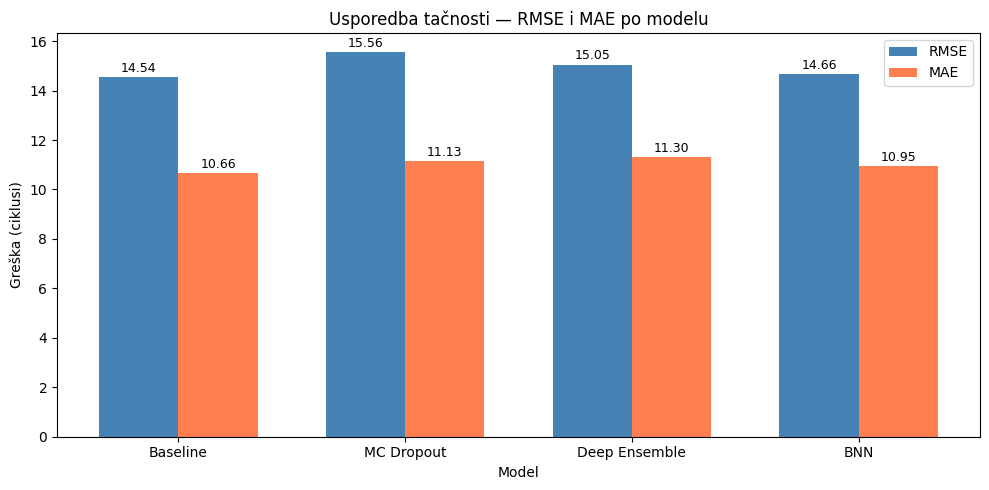

In [55]:
# ============================================================
# GRAFIČKA USPOREDBA — RMSE i MAE
# ============================================================

models      = ['Baseline', 'MC Dropout', 'Deep Ensemble', 'BNN']
rmse_values = [rmse, rmse_mc, rmse_ens, rmse_bnn]
mae_values  = [mae,  mae_mc,  mae_ens,  mae_bnn]

x = np.arange(len(models))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))

bars1 = ax.bar(x - width/2, rmse_values, width, label='RMSE', color='steelblue')
bars2 = ax.bar(x + width/2, mae_values,  width, label='MAE',  color='coral')

ax.set_xlabel('Model')
ax.set_ylabel('Greška (ciklusi)')
ax.set_title('Usporedba tačnosti — RMSE i MAE po modelu')
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.legend()

# Dodavanje vrijednosti na vrh bara
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.1,
            f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.1,
            f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

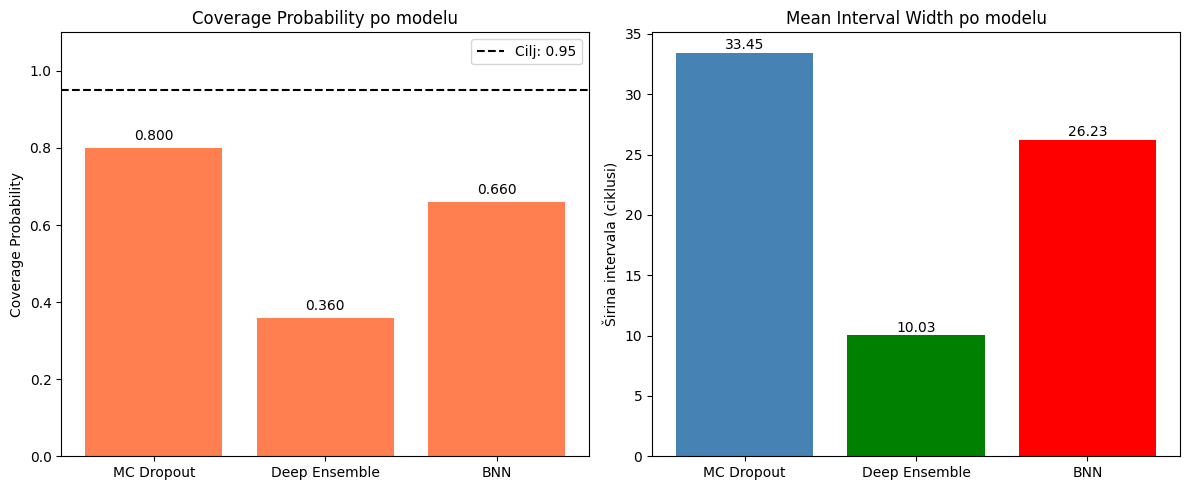

In [56]:
# ============================================================
# GRAFIČKA USPOREDBA — Coverage i Interval Width
# ============================================================

uq_models   = ['MC Dropout', 'Deep Ensemble', 'BNN']
coverages   = [mc_results['coverage'],
               ens_results['coverage'],
               bnn_results['coverage']]
widths      = [mc_results['mean_width'],
               ens_results['mean_width'],
               bnn_results['mean_width']]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Coverage
colors_coverage = ['steelblue' if c >= 0.95 else 'coral' for c in coverages]
axes[0].bar(uq_models, coverages, color=colors_coverage)
axes[0].axhline(y=0.95, color='black', linestyle='--',
                linewidth=1.5, label='Cilj: 0.95')
axes[0].set_ylim(0, 1.1)
axes[0].set_ylabel('Coverage Probability')
axes[0].set_title('Coverage Probability po modelu')
axes[0].legend()
for i, v in enumerate(coverages):
    axes[0].text(i, v + 0.02, f'{v:.3f}', ha='center', fontsize=10)

# Interval Width
axes[1].bar(uq_models, widths, color=['steelblue', 'green', 'red'])
axes[1].set_ylabel('Širina intervala (ciklusi)')
axes[1].set_title('Mean Interval Width po modelu')
for i, v in enumerate(widths):
    axes[1].text(i, v + 0.3, f'{v:.2f}', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

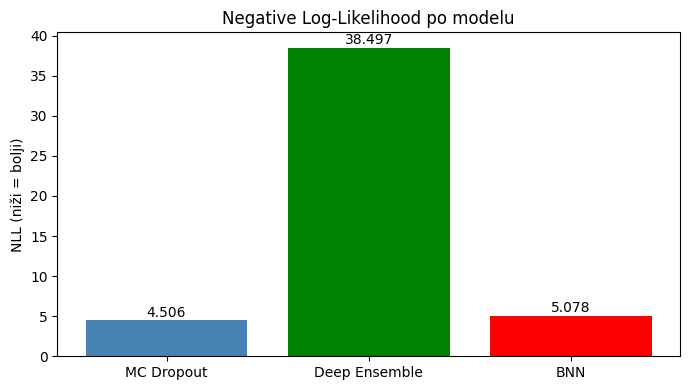

In [57]:
# ============================================================
# GRAFIČKA USPOREDBA — NLL
# ============================================================

nll_values = [mc_results['nll'],
              ens_results['nll'],
              bnn_results['nll']]

plt.figure(figsize=(7, 4))
bars = plt.bar(uq_models, nll_values, color=['steelblue', 'green', 'red'])
plt.ylabel('NLL (niži = bolji)')
plt.title('Negative Log-Likelihood po modelu')

for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.05,
             f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

### Diskusija rezultata

#### Tačnost (RMSE i MAE)

Posmatrajući isključivo metrike tačnosti, rezultati su iznenađujući —
Baseline LSTM postiže drugi najbolji RMSE (14.54), odmah iza BNN-a (14.66),
dok MC Dropout ima najlošiji RMSE (15.56) među svim modelima. Ovo naizgled
kontraintutivno ponašanje objašnjava se činjenicom da uvođenje stohastičnosti
radi kvantifikacije nesigurnosti nužno unosi određenu varijansu u predikcije.
Razlike između modela su relativno male (raspon od 14.54 do 15.56 RMSE),
što sugerira da su sve četiri metode naučile slične osnovne obrasce
degradacije iz CMAPSS dataseta.

BNN postiže najbolji RMSE (14.66) i MAE (10.95) među UQ metodama, što
potvrđuje da eksplicitno modeliranje distribucije težina ne narušava
prediktivnu sposobnost modela — naprotiv, Bayesovska regularizacija
kroz KL divergenciju djeluje kao efikasan mehanizam sprječavanja
overfittinga.

#### Kalibracija (Coverage Probability i Interval Width)

Ovo je najvažnija dimenzija evaluacije za primjenu u kritičnim sustavima
kao što je prediktivno održavanje. Model s dobrim RMSE ali lošim
coverageom nije pouzdan u praksi — operater ne može znati kada vjerovati
predikcijama modela.

Nijedan od tri modela ne postiže ciljani coverage od 0.95, što je
značajan nalaz ovog rada. MC Dropout dostiže coverage od 0.80 —
najbliži cilju, ali i dalje 15 postotnih poena ispod. Ovo znači da
svaki peti motor čiji stvarni RUL pada izvan predikcijskog intervala
ne bi bio prepoznat kao rizičan, što je neprihvatljivo u avioindustrijskim
primjenama. BNN postiže coverage od 0.66, a Deep Ensemble dramatično
najlošiji rezultat — samo 0.36.

Deep Ensemble pokazuje najozbiljniji problem kalibracije: coverage od
0.36 uz najuži interval (10.03 ciklusa) jasno indicira da model
potcjenjuje svoju nesigurnost. Svih pet modela konvergiralo je u vrlo
slična rješenja, pa je međusobna raznolikost mala i standardna
devijacija ne odražava stvarnu neizvjesnost predikcije. Ovo je poznato
ograničenje Deep Ensemble metode kada modeli dijele identičnu arhitekturu
i podatke za trening.

MC Dropout ima najširi interval (33.45 ciklusa) što objašnjava viši
coverage, ali takvi široki intervali imaju ograničenu praktičnu
upotrebljivost — preširok interval koji pokriva gotovo cijeli raspon
RUL vrijednosti ne daje operateru korisnu informaciju o tome kada
planirati servis.

#### Negative Log-Likelihood (NLL)

NLL kao kombinovana metrika tačnosti i kalibracije potvrđuje nalaze
coveragea. MC Dropout postiže najniži NLL (4.506), što ga čini
najpouzdanijim modelom kada se uzme u obzir cjelokupna distribucija
predikcija. BNN je blizu s NLL = 5.078, dok Deep Ensemble postiže
dramatično lošiji NLL od 38.497 — direktna posljedica ekstremno
uskih intervala koji ne pokrivaju stvarne vrijednosti.

#### Sažetak trade-offa: tačnost vs. kalibracija

| Kriterij | Pobjednik |
|---|---|
| Najmanji RMSE | Baseline LSTM (14.54) |
| Najmanji MAE | Baseline LSTM (10.66) |
| Najbolji coverage | MC Dropout (0.80) |
| Najuži intervali | Deep Ensemble (10.03) |
| Najbolji NLL | MC Dropout (4.506) |
| Najbolji RMSE među UQ metodama | BNN (14.66) |

Ključni zaključak je da nijedna metoda nije dominantna po svim
kriterijima istovremeno — postoji jasan trade-off između tačnosti
i kalibracije. Za primjenu u prediktivnom održavanju, gdje je
pouzdanost intervala nesigurnosti jednako važna kao i sama predikcija,
MC Dropout predstavlja najpraktičniji izbor zbog najboljeg coveragea
i NLL-a, uz prihvatljiv RMSE. BNN je teorijski najrigorozniji pristup
i postiže najbolju tačnost među UQ metodama, ali njegova kalibracija
zahtijeva dodatno podešavanje. Deep Ensemble, unatoč dobroj literaturi
koja ga preporučuje, u ovoj implementaciji pokazuje ozbiljan problem
potcjenjivanja nesigurnosti koji ga čini nepouzdanim za sigurnosno
kritične primjene bez dodatnih tehnika kao što su temperatura skaliranja
ili konformal prediction.